In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
import numpy as np
print('loaded!')

loaded!


In [2]:
# Load data
all_quits = pd.read_csv('quits_v2.csv')

# drop Name column for anonymity
all_quits = all_quits.drop('Name', axis = 1)
all_quits.head()

,program,rank,age,attendance notes,Notes,month,year
0,cardio,-,22,NaN,NaN,February,2017
1,cardio,-,27,NaN,NaN,February,2017
2,cardio,-,41,NaN,NaN,January,2017
3,cardio,-,43,NaN,NaN,January,2017
4,cardio,-,23,NaN,NaN,January,2017


In [3]:
'''
Data Cleaning steps and Reasoning

1. Include only certain programs - drop programs we're not interested in for this project
    Kickboxing /cardio classes I'm uninterested in. They have no ranks and are completely seperate programs
    from the traditional martial arts. 
    Tigers we are keeping because I view it as essentially a sub-program

2. Fix missing ranks: drop if under <5%, or impute >5%
    I added some ranks (which I outline later on) because I taught them. I knew they either:
        were black belts or
        had under 20 classes and couldn't have possibly ranked up to yellow. 

3. What to do with repeat quits? IE. someone quit at white belt then came back and trained again and quit at yellow or are still trainign?
    For students who quit, returned, and then haven't quit again: There is no information in this sheet about their re-enrollment. 
    As such: I kept them in the data. 

    For students who quit multiple times I had 2 options in my mind: Keep their latest quit or keep all. 
        Latest quit: would ignore earlier quit events and potentially biasing the analysis
        All quits: would include earlier quits and preserves full decision history of students
'''

"\nData Cleaning steps and Reasoning\n\n1. Include only certain programs - drop programs we're not interested in for this project\n    Kickboxing /cardio classes I'm uninterested in. They have no ranks and are completely seperate programs\n    from the traditional martial arts. \n    Tigers we are keeping because I view it as essentially a sub-program\n\n2. Fix missing ranks: drop if under <5%, or impute >5%\n    I added some ranks (which I outline later on) because I taught them. I knew they either:\n        were black belts or\n        had under 20 classes and couldn't have possibly ranked up to yellow. \n\n3. What to do with repeat quits? IE. someone quit at white belt then came back and trained again and quit at yellow or are still trainign?\n    For students who quit, returned, and then haven't quit again: There is no information in this sheet about their re-enrollment. \n    As such: I kept them in the data. \n\n    For students who quit multiple times I had 2 options in my mind:

In [4]:
print(all_quits['program'].unique())

['cardio' 'krav' 'kids' 'tigers' 'adults' 'kids & adults' 'teen' 'teens'
 'Teens' 'adult' 'teen/adult' 'Teen' 'kids PIF' 'Adults' 'kids regular'
 'kickboxing' 'kick-fit' 'adults ' 'Kids' 'kids 2/week' 'teeens'
 'kids 1/week' 'kid' 'beginners' 'kids/teens' 'tigers 1/week'
 'tigers/kids' 'Tigers' 'tigers regular' 'kids?' 'kickboxing ' 'kickfit']


In [5]:
# exclude all non karate or tigers programs
exclude = ['kickfit', 'kick-fit', 'kickboxing', 'kickboxing ', 'cardio', 'krav']

# filter out excluded programs
all_quits = all_quits[~all_quits['program'].isin(exclude)]

In [6]:
#1251 entries
print(all_quits.shape)

# use to see who is missing ranks
#print(all_quits.loc[all_quits['rank'].isna(), 'Name'])

# 60 missing rank
print(all_quits['rank'].isna().sum())

(1251, 7)
60


In [7]:
# Full transparency - there were 10-20 missing when the data was loaded. Many of whom I was able to correct in the original file. 
# I trained them as black belts or was able to see they attended <20 classes and could not have been anything other than a white belt. 
# with only 60 missing we're at 4.79%, under the 5% threshold. I will drop the missing for future calculations. 

In [8]:
# view different ranks
print(all_quits['rank'].unique())

['?' '1st degree' '1st Degree' '2nd degree' '3rd degree' 'black' 'Black'
 'blackbelt' 'blue' 'blue 1' 'blue 2' 'blue 3' 'blue 4' 'blue 6'
 'blue/green' 'blue/green 2' 'blue/green 4' 'blue/green 6' 'blue4' 'brown'
 'brown 4' 'brown 5' 'brown/black' 'brown/black6' 'brown6' 'first degree'
 'Green' 'green' 'green 2' 'green 3' 'green belt' 'green/red'
 'green/red 3' 'green/red 6' 'none' 'orage' 'orange' 'Orange' 'orange '
 'orange 1' 'orange 2' 'orange 3' 'orange 4' 'orange1' 'orange2' 'orange3'
 'ornage' 'purple' 'purple ' 'purple 1' 'purple 2' 'purple 3' 'purple 4'
 'Purple Blue' 'purple/blue' 'purple/blue ' 'purple/blue 2'
 'purple/blue 4' 'red' 'red 3' 'red 4' 'red 6' 'red/brown' 'red-brown'
 'student black' 'w/o 6' 'w/p' 'w/y' 'white' 'White '
 'white (former tiger)' 'white 1' 'white 2' 'white 3' 'white 4' 'white 5'
 'white 6' 'white 6?' 'White orange ' 'White yellow' 'white/blue'
 'white/blue 1' 'white/blue 5' 'white/blue 6' 'white/brown' 'white/green'
 'white/orange' 'white/orange 2'

In [9]:
'''
More data cleaning remarks:

some of these are simple typo fixes. 
Some of them are to combine two words (ie. 'white blue' should be 'white/blue')

near the end there is a comment about removing digits:
    This school adds tape stripes to belts for more small-term progress & knowledge checks
    Realistically they are still the same rank (yellow belt vs yellow belt with 2 stripes) and for analytic purposes it doesn't make sense to split them into further categories
    As a result I decided to remove their tips to have more data points at each rank and see trends over time better
'''

"\nMore data cleaning remarks:\n\nsome of these are simple typo fixes. \nSome of them are to combine two words (ie. 'white blue' should be 'white/blue')\n\nnear the end there is a comment about removing digits:\n    This school adds tape stripes to belts for more small-term progress & knowledge checks\n    Realistically they are still the same rank (yellow belt vs yellow belt with 2 stripes) and for analytic purposes it doesn't make sense to split them into further categories\n    As a result I decided to remove their tips to have more data points at each rank and see trends over time better\n"

In [10]:
# clean up ranks
all_quits['rank'] = (
    all_quits['rank']
    .str.lower()
    .str.replace('ornage', 'orange', regex=False)
    .str.replace('orage', 'orange', regex=False)

    .str.replace('student black', 'student_black', regex=False)

    .str.replace('2nd degree', 'second_degree', regex=False)
    .str.replace('3rd degree', 'third_degree', regex=False)
    .str.replace('1st degree', 'first_degree', regex=False)
    .str.replace('first degree', 'first_degree', regex=False)
    .str.replace('blackbelt', 'first_degree', regex=False)
    .str.replace(r'^black$', 'first_degree', regex = True)    

    .str.replace('purple blue', 'purple/blue', regex=False)
    .str.replace('white orange', 'white/orange', regex=False)
    .str.replace('white yellow', 'white/yellow', regex=False)
    .str.replace('whte/yellow', 'white/yellow', regex=False)
    .str.replace('white green', 'white/green', regex=False)
    .str.replace('white blue', 'white/blue', regex=False)
    .str.replace('green belt', 'green', regex=False)

    .str.replace('white (former tiger)', 'white', regex=False)
    .str.replace('white ?', 'white', regex=False)
    .str.replace('red-brown', 'red/brown', regex=False)

    # remove digits from string
    .str.replace(r'\d+', '', regex = True)

    .str.replace('none', '', regex = False)
    .str.replace('?', '', regex = False)
    .str.strip()
    .replace('', pd.NA)
)


In [11]:
# drop NA ranks
all_quits= all_quits.dropna(subset = ['rank'])

---

# Quits By Rank

In [12]:
# set up belt rank order
belt_rank_order = ['white', 'white/yellow', 'white/orange', 'white/purple', 'white/blue', 'white/green', 'white/red', 'white/brown', 
                   'yellow', 'orange', 'purple', 'purple/blue', 'blue', 'blue/green', 'green', 'green/red',
                   'red', 'red/brown', 'brown', 'brown/black', 'student_black', 'first_degree', 'second_degree', 'third_degree']



In [13]:
# Sort ranks by belt-rank order
all_quits['rank'] = pd.Categorical(all_quits['rank'], categories= belt_rank_order, ordered = True)
sorted_karate_quits = all_quits.sort_values(by = 'rank')

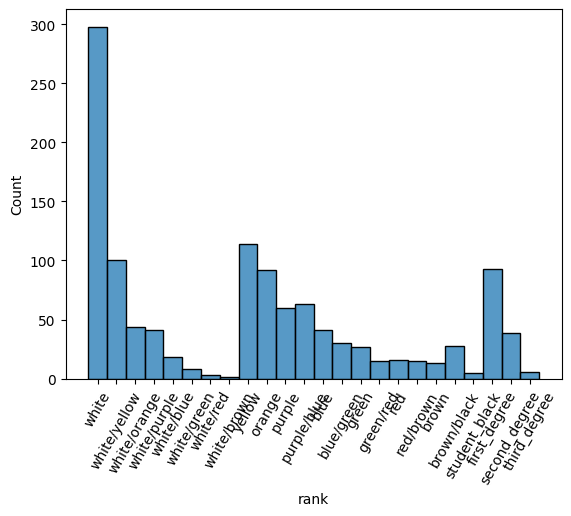

In [14]:
ax = sns.histplot(sorted_karate_quits['rank'])
plt.xticks(rotation = 60)
plt.show()

In [ ]:
# check all programs still in dataframe
print(all_quits['program'].unique())

# exclude tigers programs to see just karate belts
# Tigers are 4-6 year olds and are essentially beginners inbetween the first two belts
tigers = ['tigers', 'tigers/kids', 'tigers 1/week', 'tigers regular']
karate_quits = all_quits[~all_quits['program'].isin(tigers)]

['adults' 'kids' 'kids & adults' 'teen' 'teens' 'Teens' 'adult'
 'teen/adult' 'Teen' 'kids PIF' 'Adults' 'kids regular' 'adults ' 'Kids'
 'kids 2/week' 'teeens' 'tigers' 'kids 1/week' 'kid' 'beginners'
 'kids/teens' 'tigers 1/week' 'tigers/kids' 'Tigers' 'tigers regular'
 'kids?']


In [16]:
# set up belt rank order
no_tiger_belt_rank_order = ['white',
                   'yellow', 'orange', 'purple', 'purple/blue', 'blue', 'blue/green', 'green', 'green/red',
                   'red', 'red/brown', 'brown', 'brown/black', 'student_black', 'first_degree', 'second_degree', 'third_degree']

karate_quits['rank'] = pd.Categorical(karate_quits['rank'], categories= no_tiger_belt_rank_order, ordered = True)
sorted_no_tiger_karate_quits = karate_quits.sort_values(by = 'rank')

C:\Users\crees\AppData\Local\Temp\ipykernel_424\1100362113.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  karate_quits['rank'] = pd.Categorical(karate_quits['rank'], categories= no_tiger_belt_rank_order, ordered = True)


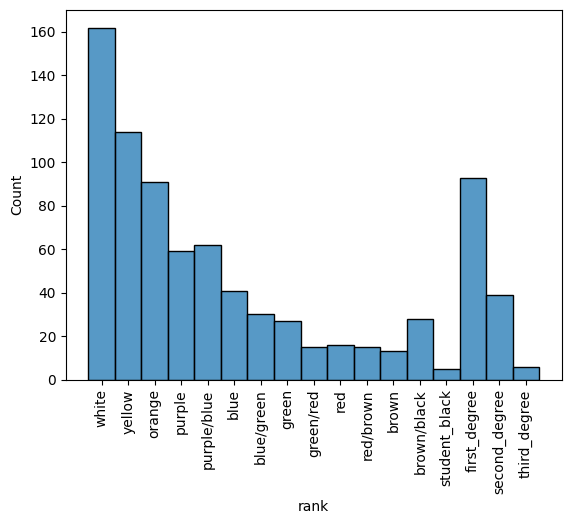

In [17]:
ax = sns.histplot(sorted_no_tiger_karate_quits['rank'])
plt.xticks(rotation = 90)
plt.show()

In [ ]:
'''
This is kind of what I figured was happening. 
1. There's a massive spike of White belts quitting right away. This is combo of someone trying karate then quitting and Tigers not adjusting to Kids classes.
    I'll check all tiger belts combined where they're at. Though some may have been marked as White when switching to the Kids program
2. Another small uptick at purple/blue
3. A big spike at brown black (sharp drop at student_black)
4. And another spike at first_degree. This makes sense for 2 reasons:
    1. Achieve a big goal and it's hard to stay motivated
    2. That rank is generally held for 8 times as long as the other belts
'''

"\nThis is kind of what I figured was happening. \nThere's a massive spike of White belts quitting right away. This is combo of someone trying it then quitting and Tigers not adjusting to Kids classes.\n    I'll check all tiger belts combined where they're at. Though some may have been marked as White when switching\nAnother small uptick at purple/blue\nA big spike at brown black (sharp drop at student_black)\nAnd another spike at first_degree. This makes sense for 2 reasons:\n    1. Achieve a big goal and it's hard to stay motivated\n    2. That rank is generally held for 8 times as long as the other belts\n"

In [19]:
# what happens if all tiger belts combined into one were shown along with the martial arts belts?
# Just interested in how many quits we have from that program
tiger_belt_dict = {
    'white/yellow': 'tiger_belt',
    'white/orange': 'tiger_belt',
    'white/purple': 'tiger_belt',
    'white/blue': 'tiger_belt',
    'white/green': 'tiger_belt',
    'white/red': 'tiger_belt',
    'white/brown': 'tiger_belt',
}
tiger_joined_quits = all_quits.copy()
tiger_joined_quits['rank'] = all_quits['rank'].replace(tiger_belt_dict)

C:\Users\crees\AppData\Local\Temp\ipykernel_424\1765207101.py:13: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  tiger_joined_quits['rank'] = all_quits['rank'].replace(tiger_belt_dict)


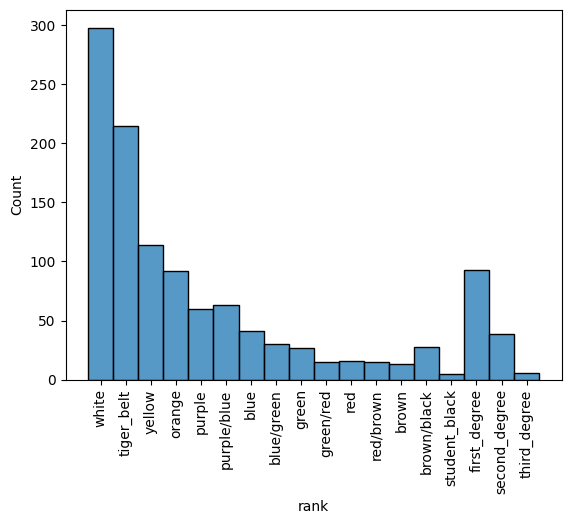

In [20]:
sns.histplot(tiger_joined_quits['rank'])
plt.xticks(rotation = 90)
plt.show()

In [21]:
print(tiger_joined_quits.shape)

(1188, 7)


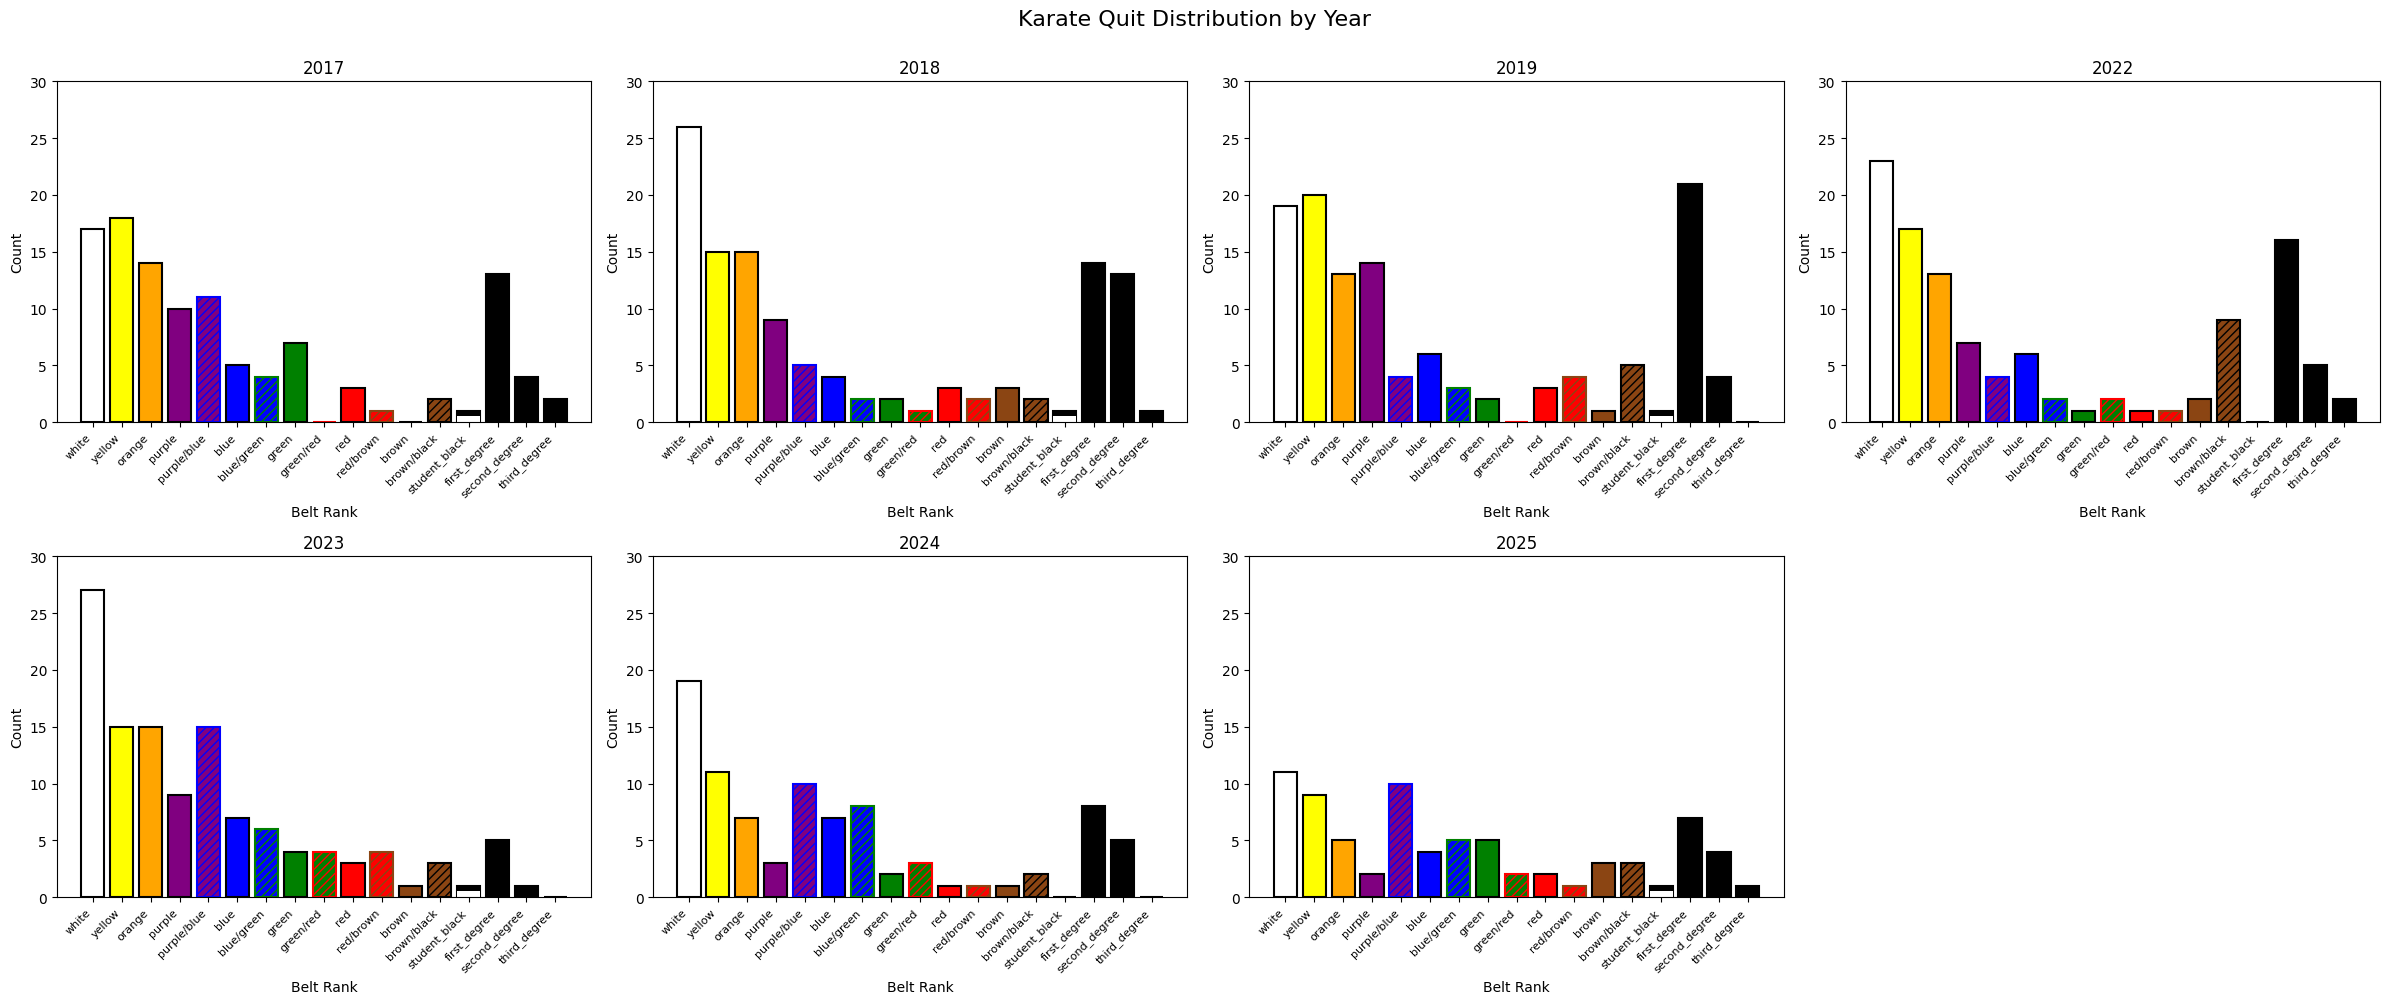

In [22]:
# exclude 2020 and 2021 because of incomplete data - result of COVID_19
# exclude 2016 because it only contains 2 months of data
iterable_years = [2017, 2018, 2019, 2022, 2023, 2024, 2025]
color_map = {
    'brown': 'saddlebrown',
    'white': 'white',
    'yellow': 'yellow',
    'orange': 'orange',
    'purple': 'purple',
    'blue': 'blue',
    'green': 'green',
    'red': 'red',
    'black': 'black'
}

# Create subplots - all in one figure
fig, axes = plt.subplots(2, 4, figsize=(24, 10))  # 2 rows, 4 columns
axes = axes.flatten()  # Flatten to make it easier to iterate

for idx, filtered_year in enumerate(iterable_years):
    ax = axes[idx]
    
    # Count values
    filtered_ = karate_quits[karate_quits['year'] == filtered_year]
    counts = Counter(filtered_['rank'])
    counts_ordered = [counts.get(belt, 0) for belt in no_tiger_belt_rank_order]
    
    # Plot bars
    x_pos = np.arange(len(no_tiger_belt_rank_order))
    bars = ax.bar(x_pos, counts_ordered, edgecolor='black', linewidth=1.5)
    
    # Color each bar (same coloring logic as before)
    for i, (bar, belt) in enumerate(zip(bars, no_tiger_belt_rank_order)):
        if belt == 'student_black':
            x = bar.get_x()
            width = bar.get_width()
            height = bar.get_height()
            bar.set_facecolor('none')
            
            rect1 = mpatches.Rectangle((x, 0), width, height/2, 
                                       facecolor='white', edgecolor='none')
            rect2 = mpatches.Rectangle((x, height/2), width, height/2, 
                                       facecolor='black', edgecolor='none')
            ax.add_patch(rect1)
            ax.add_patch(rect2)
        elif 'degree' in belt:
            bar.set_facecolor('black')
        elif '/' in belt:
            color1, color2 = belt.split('/')
            color1 = color_map.get(color1, color1)
            color2 = color_map.get(color2, color2)
            bar.set_facecolor(color1)
            bar.set_hatch('////')
            bar.set_edgecolor(color2)
        else:
            bar.set_facecolor(color_map.get(belt, belt))
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(no_tiger_belt_rank_order, rotation=45, ha='right', fontsize=8)
    ax.set_xlabel('Belt Rank', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(f'{filtered_year}', fontsize=12)
    ax.set_ylim(0, 30)  # Set y-axis to always go from 0 to 30

# Hide the extra subplot (we have 7 years, 8 subplot spaces)
axes[-1].axis('off')

plt.suptitle('Karate Quit Distribution by Year', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

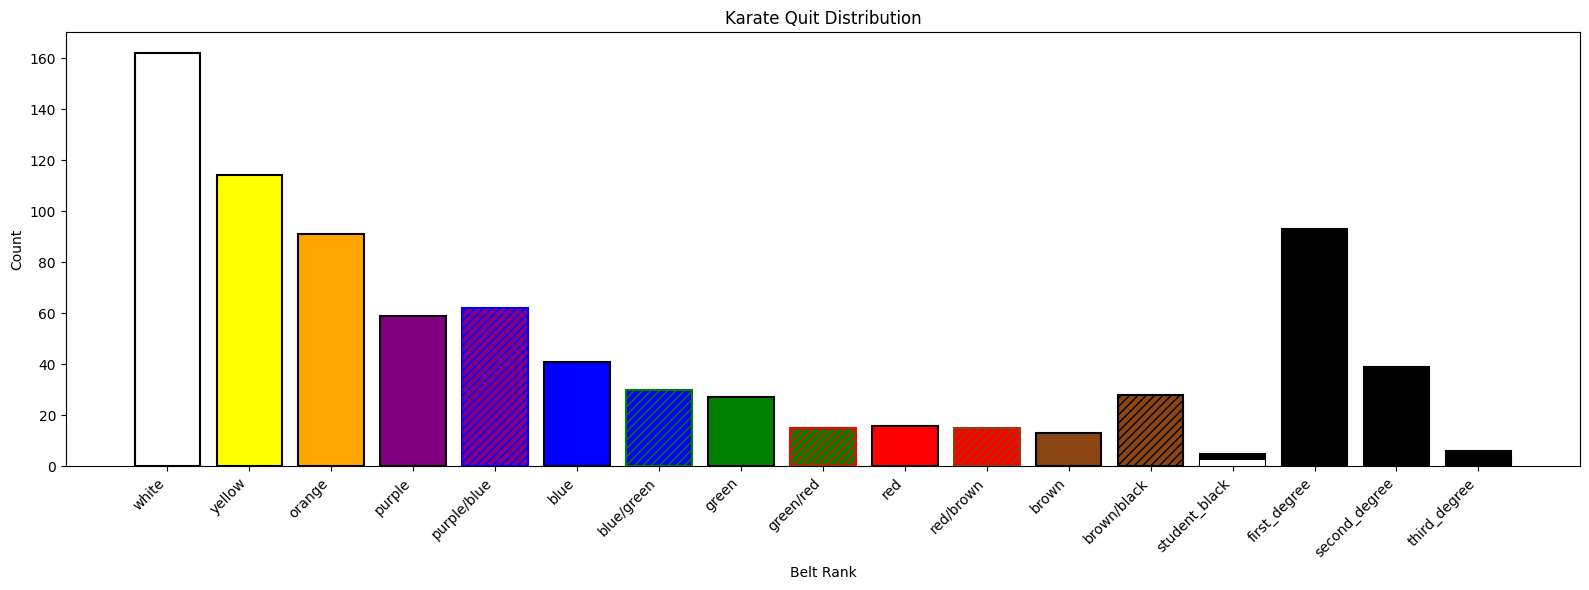

In [23]:
# 
color_map = {
    'brown': 'saddlebrown',
    'white': 'white',
    'yellow': 'yellow',
    'orange': 'orange',
    'purple': 'purple',
    'blue': 'blue',
    'green': 'green',
    'red': 'red',
    'black': 'black'
}

# Filter years - currently all years 
filtered_years = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
all_years_data = karate_quits[karate_quits['year'].isin(filtered_years)]

# Count values across all years
counts = Counter(all_years_data['rank'])
counts_ordered = [counts.get(belt, 0) for belt in no_tiger_belt_rank_order]

# Create figure,
fig, ax = plt.subplots(figsize=(16, 6))

# Plot bars
x_pos = np.arange(len(no_tiger_belt_rank_order))
bars = ax.bar(x_pos, counts_ordered, edgecolor='black', linewidth=1.5)

# Color each bar
for i, (bar, belt) in enumerate(zip(bars, no_tiger_belt_rank_order)):
    if belt == 'student_black':
        x = bar.get_x()
        width = bar.get_width()
        height = bar.get_height()
        bar.set_facecolor('none')
        
        rect1 = mpatches.Rectangle((x, 0), width, height/2, 
                                   facecolor='white', edgecolor='none')
        rect2 = mpatches.Rectangle((x, height/2), width, height/2, 
                                   facecolor='black', edgecolor='none')
        ax.add_patch(rect1)
        ax.add_patch(rect2)
    elif 'degree' in belt:
        bar.set_facecolor('black')
    elif '/' in belt:
        color1, color2 = belt.split('/')
        color1 = color_map.get(color1, color1)
        color2 = color_map.get(color2, color2)
        bar.set_facecolor(color1)
        bar.set_hatch('////')
        bar.set_edgecolor(color2)
    else:
        bar.set_facecolor(color_map.get(belt, belt))

ax.set_xticks(x_pos)
ax.set_xticklabels(no_tiger_belt_rank_order, rotation=45, ha='right')
ax.set_xlabel('Belt Rank')
ax.set_ylabel('Count')
ax.set_title('Karate Quit Distribution')
plt.tight_layout()
plt.show()

In [24]:
# set up belt rank order
joined_tiger_belt_rank_order = ['white', 'tiger_belt',
                   'yellow', 'orange', 'purple', 'purple/blue', 'blue', 'blue/green', 'green', 'green/red',
                   'red', 'red/brown', 'brown', 'brown/black', 'student_black', 'first_degree', 'second_degree', 'third_degree']

tiger_joined_quits['rank'] = pd.Categorical(tiger_joined_quits['rank'], categories= joined_tiger_belt_rank_order, ordered = True)
sorted_tiger_karate_quits = tiger_joined_quits.sort_values(by = 'rank')


---

# Changes based on Month and Year

In [25]:
# count quits by year to see trends
yearly_quits = karate_quits.groupby('year').size().reset_index(name = 'total_quits')
# yearly_quits_filt = yearly_quits[~yearly_quits['year'].isin([2016, 2020, 2021])]

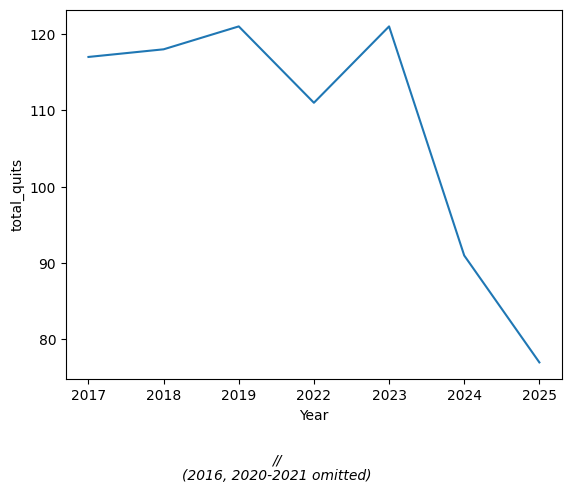

In [26]:
# remove years 2016, 2020, 2021
yearly_quits_filtered = yearly_quits[~yearly_quits['year'].isin([2016, 2020, 2021])].copy()
yearly_quits_filtered['year_str'] = yearly_quits_filtered['year'].astype(str)
ax = sns.lineplot(data=yearly_quits_filtered, x='year_str', y='total_quits')
plt.xlabel('Year')

# Add break annotation
plt.text(2.5, ax.get_ylim()[1]*0.5, '//\n(2016, 2020-2021 omitted)', 
         ha='center', fontsize=10, style='italic')
plt.show()

In [ ]:
#print(karate_quits[(karate_quits['year'] == 2018) & (karate_quits['rank'] =='white')].shape)

(26, 7)


In [ ]:
'''
Future Ideas:

1. View monthly or quarterly quits

2. See if there are enrollment numbers!
    Would allow for net new analysis (maybe some months are more volatile but generally positive)

3. dive into "Attendance notes" and "notes" columns
    Text-rich data that could be leveraged - 60% of which has data in "notes" column
    Only 13% of Attendance notes have data

'''

In [ ]:
# print(f'Percent of notes column with data: {round(1 - all_quits['Notes'].isna().sum() / len(all_quits['Notes']), 5) *100}%')
# print(f'Percent of notes column with data: {round(1 - all_quits['attendance notes'].isna().sum() / len(all_quits['Notes']), 5)*100}%')

Percent of notes column with data: 57.997%
Percent of notes column with data: 13.215%
